In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

In [2]:
def find_event_files(logdir: str):
    # recursively find tfevent files
    return glob.glob(os.path.join(logdir, "**", "events.out.tfevents.*"), recursive=True)


def load_scalar_from_events(event_files, tag):
    """
    Load scalar events (step, value) from possibly multiple event files.
    Returns sorted arrays: steps, values.
    """
    steps_all, vals_all = [], []
    for f in event_files:
        ea = EventAccumulator(f, size_guidance={"scalars": 0})
        ea.Reload()
        if tag not in ea.Tags().get("scalars", []):
            continue
        events = ea.Scalars(tag)
        steps_all.extend([e.step for e in events])
        vals_all.extend([e.value for e in events])

    if len(steps_all) == 0:
        raise ValueError(f"No scalar events found for tag '{tag}'. "
                         f"Checked {len(event_files)} event file(s).")

    steps = np.array(steps_all, dtype=np.int64)
    vals = np.array(vals_all, dtype=np.float64)

    # sort by step
    idx = np.argsort(steps)
    steps, vals = steps[idx], vals[idx]

    # If there are duplicate steps, keep the last value for each step
    uniq_steps, last_idx = np.unique(steps, return_index=True)
    # last_idx gives first occurrence; we want last. Do a small trick:
    # map each step to the last occurrence index
    _, inv = np.unique(steps[::-1], return_index=True)
    last_occ = (len(steps) - 1) - inv
    last_occ_sorted = np.sort(last_occ)
    steps, vals = steps[last_occ_sorted], vals[last_occ_sorted]
    return steps, vals


def rolling_mean_std(y, window_points: int):
    """
    Rolling mean/std over a fixed number of points.
    For RL logs, points are typically episode summaries sampled over time.
    """
    if window_points <= 1:
        return y, np.zeros_like(y)

    y = np.asarray(y, dtype=np.float64)
    csum = np.cumsum(np.insert(y, 0, 0.0))
    csum2 = np.cumsum(np.insert(y * y, 0, 0.0))

    n = len(y)
    means = np.empty(n, dtype=np.float64)
    stds = np.empty(n, dtype=np.float64)

    for i in range(n):
        start = max(0, i - window_points + 1)
        count = i - start + 1
        s1 = csum[i + 1] - csum[start]
        s2 = csum2[i + 1] - csum2[start]
        m = s1 / count
        v = max(0.0, (s2 / count) - m * m)
        means[i] = m
        stds[i] = np.sqrt(v)

    return means, stds


def interp_to_grid(x, y, grid):
    """
    Interpolate y(x) onto a common x grid.
    Assumes x is increasing. Out-of-range becomes NaN.
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    grid = np.asarray(grid, dtype=np.float64)

    if len(x) < 2:
        out = np.full_like(grid, np.nan, dtype=np.float64)
        if len(x) == 1:
            out[grid == x[0]] = y[0]
        return out

    out = np.interp(grid, x, y, left=np.nan, right=np.nan)
    out[grid < x[0]] = np.nan
    out[grid > x[-1]] = np.nan
    return out


def plot_three_models(
    model_dirs,
    labels,
    tag="rollout/ep_rew_mean",   # common in SB3; change if needed
    xmax=100_000,
    grid_points=500,
    window_points=25,            # smoothing in "number of logged points"
    shade="std",                 # "std", "ci", or None
):
    grid = np.linspace(0, xmax, grid_points)

    plt.figure(figsize=(9, 5))
    for d, label in zip(model_dirs, labels):
        event_files = find_event_files(d)
        if not event_files:
            raise FileNotFoundError(f"No event files found under: {d}")

        steps, vals = load_scalar_from_events(event_files, tag=tag)

        # Restrict to [0, xmax]
        mask = (steps >= 0) & (steps <= xmax)
        steps, vals = steps[mask], vals[mask]

        # Smooth in point-space
        mean_s, std_s = rolling_mean_std(vals, window_points=window_points)

        # Interp to common grid for clean curves
        mean_g = interp_to_grid(steps, mean_s, grid)
        std_g = interp_to_grid(steps, std_s, grid)

        plt.plot(grid, mean_g, label=label)

        if shade in ("std", "ci"):
            if shade == "std":
                lo, hi = mean_g - std_g, mean_g + std_g
            else:
                # crude CI from rolling std: CI ≈ 1.96 * std / sqrt(n_window)
                # Here n_window ≈ window_points (best-effort)
                n_eff = max(2, window_points)
                ci = 1.96 * (std_g / np.sqrt(n_eff))
                lo, hi = mean_g - ci, mean_g + ci

            plt.fill_between(grid, lo, hi, alpha=0.2)

    plt.xlim(0, xmax)
    plt.xlabel("Timesteps")
    plt.ylabel("Episode reward (rolling mean)")
    plt.title("RL Training Curves")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()




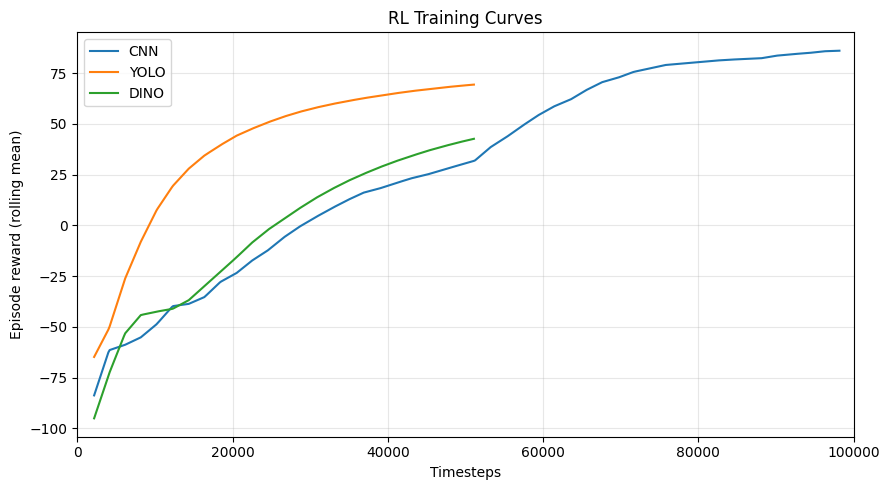

In [14]:
model_dirs = [
    "Logs/cnn",
    "Logs/yolo",
    "Logs/dino",
]
labels = ["CNN", "YOLO", "DINO"]

plot_three_models(
    model_dirs=model_dirs,
    labels=labels,
    tag="rollout/ep_rew_mean",  # <-- change this tag to match your logs
    xmax=100_000,
    grid_points=600,
    window_points=25,
    shade="None",                # "std", "ci", or None
)

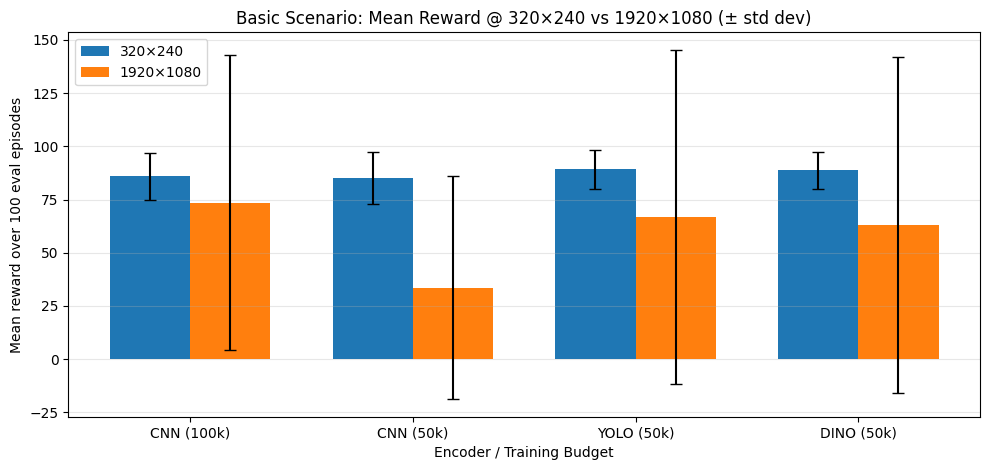

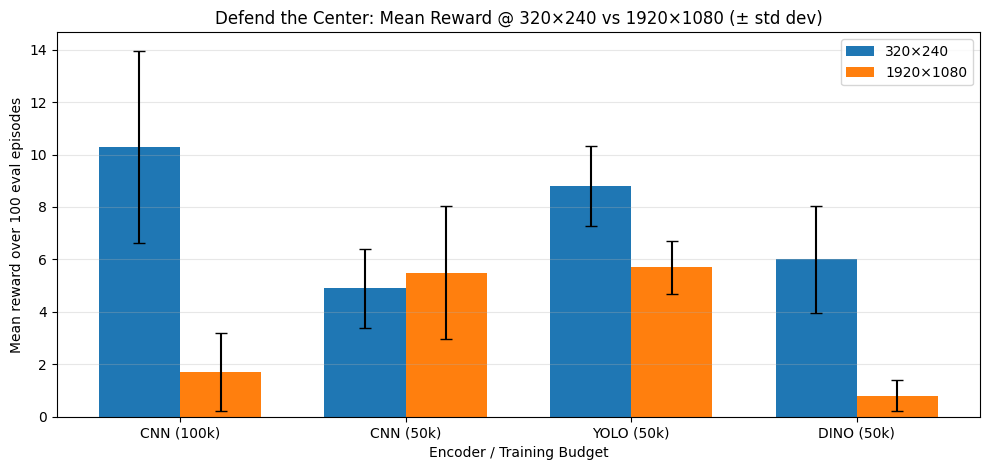

In [15]:
import numpy as np
import matplotlib.pyplot as plt

groups = ["CNN (100k)", "CNN (50k)", "YOLO (50k)", "DINO (50k)"]

# ---------- BASIC SCENARIO ----------
basic_320_mean = np.array([85.9, 85.03, 89.25, 88.84])
basic_320_std  = np.array([11.132385189167685, 12.09830979930668, 9.129485199067908, 8.716329502720741])

basic_1080_mean = np.array([73.53, 33.68, 66.76, 63.12])
basic_1080_std  = np.array([69.3902666085093, 52.4785441871247, 78.56260178991019, 79.01547696495922])

# ---------- DEFEND THE CENTER ----------
dtc_320_mean = np.array([10.3, 4.9, 8.8, 6.0])
dtc_320_std  = np.array([3.661966684720111, 1.5132745950421556, 1.5362291495737217, 2.04939015319192])

dtc_1080_mean = np.array([1.7, 5.5, 5.7, 0.8])
dtc_1080_std  = np.array([1.4866068747318506, 2.539685019840059, 1.004987562112089, 0.6000000000000001])


def grouped_bar(means_a, stds_a, means_b, stds_b, title, label_a="320×240", label_b="1920×1080"):
    x = np.arange(len(groups))
    width = 0.36

    fig, ax = plt.subplots(figsize=(10, 4.8))

    ax.bar(x - width/2, means_a, width, yerr=stds_a, capsize=4, label=label_a)
    ax.bar(x + width/2, means_b, width, yerr=stds_b, capsize=4, label=label_b)

    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=0)
    ax.set_xlabel("Encoder / Training Budget")
    ax.set_ylabel("Mean reward over 100 eval episodes")
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    return fig, ax


# Make the plots
grouped_bar(
    basic_320_mean, basic_320_std,
    basic_1080_mean, basic_1080_std,
    title="Basic Scenario: Mean Reward @ 320×240 vs 1920×1080 (± std dev)"
)

grouped_bar(
    dtc_320_mean, dtc_320_std,
    dtc_1080_mean, dtc_1080_std,
    title="Defend the Center: Mean Reward @ 320×240 vs 1920×1080 (± std dev)"
)

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image

def apply_and_plot(
    image_path: str,
    processes: list,
    titles: list | None = None,
    figsize=(16, 5),
    save_path: str | None = None,
):
    """
    Apply a list of image-processing functions to an input image and plot:
      [Original | proc1 | proc2 | proc3 | ...] side-by-side.

    Parameters
    ----------
    image_path : str
        Path to the input image.
    processes : list
        List of callables, each like: f(img) -> output_image.
        Each function may accept either a PIL.Image or a numpy array.
    titles : list | None
        Titles for each panel. If None, auto-generates.
    figsize : tuple
        Matplotlib figure size.
    save_path : str | None
        If provided, saves the figure to this path.
    """

    # ---- helpers ----
    def to_pil(x):
        """Convert numpy/PIL output to PIL.Image safely."""
        if isinstance(x, Image.Image):
            return x
        x = np.asarray(x)
        # If float in [0,1], scale to [0,255]
        if x.dtype.kind == "f":
            x = np.clip(x, 0.0, 1.0) * 255.0
        x = np.clip(x, 0, 255).astype(np.uint8)

        # Handle grayscale
        if x.ndim == 2:
            return Image.fromarray(x, mode="L")
        # Handle RGBA/RGB
        if x.ndim == 3 and x.shape[2] == 4:
            return Image.fromarray(x, mode="RGBA")
        if x.ndim == 3 and x.shape[2] == 3:
            return Image.fromarray(x, mode="RGB")
        raise ValueError(f"Unsupported output shape: {x.shape}")

    def to_display_array(pil_img: Image.Image):
        """Return array suitable for plt.imshow."""
        arr = np.array(pil_img)
        # For grayscale, keep as 2D
        return arr

    # ---- load original ----
    orig_pil = Image.open(image_path).convert("RGB")

    # ---- run processes ----
    outputs = []
    for i, fn in enumerate(processes):
        try:
            out = fn(orig_pil)  # try PIL first
        except Exception:
            out = fn(np.array(orig_pil))  # fallback to numpy
        outputs.append(to_pil(out))

    # ---- titles ----
    n = 1 + len(outputs)
    if titles is None:
        titles = ["Original"] + [f"Process {i+1}" for i in range(len(outputs))]
    else:
        if len(titles) != n:
            raise ValueError(f"titles must have length {n} (Original + {len(outputs)} outputs)")

    # ---- plot ----
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    all_imgs = [orig_pil] + outputs
    for ax, img, t in zip(axes, all_imgs, titles):
        arr = to_display_array(img)
        if arr.ndim == 2:
            ax.imshow(arr, cmap="gray")
        else:
            ax.imshow(arr)
        ax.set_title(t)
        ax.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()





=== Speed Summary (from TensorBoard logs) ===
Method   Avg FPS  FPS Std  Avg Step Time (s/step)  Step Time Std       Source
   CNN 24.040000 3.834927                0.042410       0.005425 tag:time/fps
  DINO 18.076923 3.616203                0.057081       0.009699 tag:time/fps
  YOLO 16.153846 1.405119                0.062293       0.004857 tag:time/fps


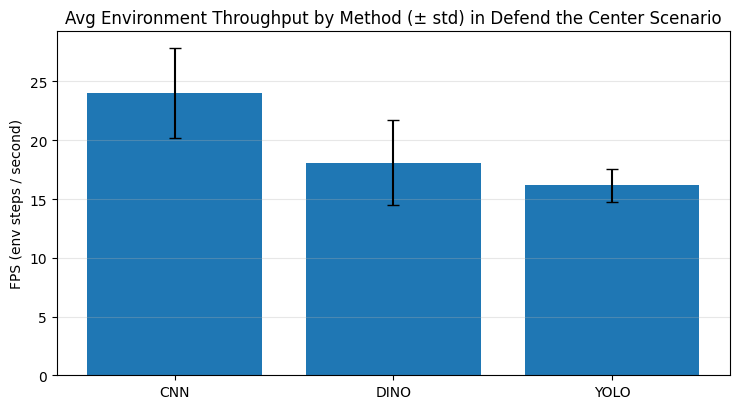

In [21]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


# -----------------------------
# Config
# -----------------------------
ROOT = "logs"
METHOD_DIRS = {
    "CNN":  os.path.join(ROOT, "cnnD"),
    "YOLO": os.path.join(ROOT, "yoloD"),
    "DINO": os.path.join(ROOT, "dinoD"),
}

# Tags we try first (if present, we use them directly)
FPS_TAG_CANDIDATES = [
    "rollout/fps", "time/fps", "fps", "perf/fps", "train/fps", "env/fps"
]
STEP_TIME_TAG_CANDIDATES = [
    "time/step", "step_time", "rollout/step_time", "perf/step_time", "env/step_time"
]

# For fallback estimation from wall_time vs step, we try to use a reward-ish scalar first:
REFERENCE_TAG_CANDIDATES = [
    "rollout/ep_rew_mean", "episode_reward", "train/episode_reward",
    "charts/episodic_return", "eval/mean_reward",
]

# Smoothing: compute fps from step deltas over this many consecutive points
MIN_POINTS = 10  # minimum scalar points needed to estimate reliably


# -----------------------------
# Helpers
# -----------------------------
def find_event_files(logdir: str):
    return glob.glob(os.path.join(logdir, "**", "events.out.tfevents.*"), recursive=True)

def load_event_accumulators(event_files):
    eas = []
    for f in event_files:
        ea = EventAccumulator(f, size_guidance={"scalars": 0})
        ea.Reload()
        eas.append(ea)
    return eas

def all_scalar_tags(eas):
    tags = set()
    for ea in eas:
        tags.update(ea.Tags().get("scalars", []))
    return sorted(tags)

def read_scalar_series(eas, tag):
    """Return arrays step, wall_time, value merged across files, sorted by step then wall_time."""
    steps, times, vals = [], [], []
    for ea in eas:
        if tag not in ea.Tags().get("scalars", []):
            continue
        evs = ea.Scalars(tag)
        for e in evs:
            steps.append(e.step)
            times.append(e.wall_time)  # seconds since epoch
            vals.append(e.value)
    if not steps:
        return None

    steps = np.asarray(steps, dtype=np.int64)
    times = np.asarray(times, dtype=np.float64)
    vals  = np.asarray(vals,  dtype=np.float64)

    # Sort by (step, wall_time)
    idx = np.lexsort((times, steps))
    return steps[idx], times[idx], vals[idx]

def pick_first_existing_tag(tags_available, candidates):
    for t in candidates:
        if t in tags_available:
            return t
    return None

def estimate_fps_from_walltime(steps, times):
    """
    FPS ~= delta_step / delta_time. Uses consecutive deltas and returns:
      fps_mean, fps_std, step_time_mean, step_time_std
    """
    if len(steps) < MIN_POINTS:
        return None

    dstep = np.diff(steps).astype(np.float64)
    dtime = np.diff(times).astype(np.float64)

    # Filter invalid / zero intervals
    mask = (dstep > 0) & (dtime > 0)
    dstep, dtime = dstep[mask], dtime[mask]
    if len(dstep) < MIN_POINTS:
        return None

    fps = dstep / dtime
    # Robust filtering of extreme outliers (optional but helps messy logs)
    lo, hi = np.percentile(fps, [5, 95])
    fps = fps[(fps >= lo) & (fps <= hi)]
    if len(fps) < MIN_POINTS:
        return None

    step_time = 1.0 / fps
    return (
        float(np.mean(fps)), float(np.std(fps, ddof=1)) if len(fps) > 1 else 0.0,
        float(np.mean(step_time)), float(np.std(step_time, ddof=1)) if len(step_time) > 1 else 0.0
    )

def compute_method_speed(logdir: str):
    event_files = find_event_files(logdir)
    if not event_files:
        raise FileNotFoundError(f"No event files found under: {logdir}")

    eas = load_event_accumulators(event_files)
    tags = all_scalar_tags(eas)

    fps_tag = pick_first_existing_tag(tags, FPS_TAG_CANDIDATES)
    st_tag  = pick_first_existing_tag(tags, STEP_TIME_TAG_CANDIDATES)

    # 1) If there is an FPS tag, use it directly
    if fps_tag is not None:
        series = read_scalar_series(eas, fps_tag)
        if series is not None:
            _, _, fps_vals = series
            # Trim out crazy outliers just in case
            fps_vals = fps_vals[np.isfinite(fps_vals)]
            if len(fps_vals) >= MIN_POINTS:
                fps_mean = float(np.mean(fps_vals))
                fps_std  = float(np.std(fps_vals, ddof=1)) if len(fps_vals) > 1 else 0.0
                step_time_vals = 1.0 / np.maximum(fps_vals, 1e-12)
                st_mean = float(np.mean(step_time_vals))
                st_std  = float(np.std(step_time_vals, ddof=1)) if len(step_time_vals) > 1 else 0.0
                return dict(source=f"tag:{fps_tag}", fps_mean=fps_mean, fps_std=fps_std,
                            step_time_mean=st_mean, step_time_std=st_std)

    # 2) If there is a step-time tag, use it directly
    if st_tag is not None:
        series = read_scalar_series(eas, st_tag)
        if series is not None:
            _, _, st_vals = series
            st_vals = st_vals[np.isfinite(st_vals)]
            if len(st_vals) >= MIN_POINTS:
                st_mean = float(np.mean(st_vals))
                st_std  = float(np.std(st_vals, ddof=1)) if len(st_vals) > 1 else 0.0
                fps_vals = 1.0 / np.maximum(st_vals, 1e-12)
                fps_mean = float(np.mean(fps_vals))
                fps_std  = float(np.std(fps_vals, ddof=1)) if len(fps_vals) > 1 else 0.0
                return dict(source=f"tag:{st_tag}", fps_mean=fps_mean, fps_std=fps_std,
                            step_time_mean=st_mean, step_time_std=st_std)

    # 3) Fallback: estimate FPS from wall_time vs global_step on some reference scalar
    ref_tag = pick_first_existing_tag(tags, REFERENCE_TAG_CANDIDATES)
    if ref_tag is None and len(tags) > 0:
        # last resort: use the first scalar tag
        ref_tag = tags[0]

    if ref_tag is None:
        raise RuntimeError(f"No scalar tags found in {logdir} — cannot estimate FPS.")

    series = read_scalar_series(eas, ref_tag)
    if series is None:
        raise RuntimeError(f"Could not read reference scalar tag '{ref_tag}' in {logdir}.")

    steps, times, _ = series
    est = estimate_fps_from_walltime(steps, times)
    if est is None:
        raise RuntimeError(
            f"Not enough usable points to estimate FPS from tag '{ref_tag}' in {logdir}."
        )

    fps_mean, fps_std, st_mean, st_std = est
    return dict(source=f"estimated_from:{ref_tag}", fps_mean=fps_mean, fps_std=fps_std,
                step_time_mean=st_mean, step_time_std=st_std)


# -----------------------------
# Main: compute + plot
# -----------------------------
rows = []
for method, path in METHOD_DIRS.items():
    stats = compute_method_speed(path)
    rows.append({
        "Method": method,
        "Avg FPS": stats["fps_mean"],
        "FPS Std": stats["fps_std"],
        "Avg Step Time (s/step)": stats["step_time_mean"],
        "Step Time Std": stats["step_time_std"],
        "Source": stats["source"],
    })

df = pd.DataFrame(rows).sort_values("Method")
print("\n=== Speed Summary (from TensorBoard logs) ===")
print(df.to_string(index=False))

# --- Bar chart: FPS ---
x = np.arange(len(df))
plt.figure(figsize=(7.5, 4.2))
plt.bar(x, df["Avg FPS"].values, yerr=df["FPS Std"].values, capsize=4)
plt.xticks(x, df["Method"].values)
plt.ylabel("FPS (env steps / second)")
plt.title("Avg Environment Throughput by Method (± std) in Defend the Center Scenario")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# If you prefer step time (s/step) instead of FPS, swap these lines:
# plt.bar(x, df["Avg Step Time (s/step)"].values, yerr=df["Step Time Std"].values, capsize=4)
# plt.ylabel("Seconds per env step")


In [29]:
import os, glob
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

LOGS = {
    "CNN":  "logs/cnn",
    "YOLO": "logs/yolo",
    "DINO": "logs/dino",
}

TARGET_REWARD = 80.0     # <-- set X here
MAX_STEPS = 100_000
SMOOTH_WINDOW = 1       # in "points" (scalar samples), not env-steps

# Reward tags we try in order (common across RL setups)
REWARD_TAG_CANDIDATES = [
    "eval/mean_reward",
    "rollout/ep_rew_mean",
    "train/episode_reward",
    "episode_reward",
    "charts/episodic_return",
    "episodic_return",
    "reward",
]

def find_event_files(logdir: str):
    return glob.glob(os.path.join(logdir, "**", "events.out.tfevents.*"), recursive=True)

def load_all_scalar_tags(event_files):
    tags = set()
    for f in event_files:
        ea = EventAccumulator(f, size_guidance={"scalars": 0})
        ea.Reload()
        tags.update(ea.Tags().get("scalars", []))
    return sorted(tags)

def pick_reward_tag(tags):
    for t in REWARD_TAG_CANDIDATES:
        if t in tags:
            return t
    # fallback: pick something that "looks like" reward/return
    for t in tags:
        low = t.lower()
        if "rew" in low or "reward" in low or "return" in low:
            return t
    return None

def read_scalar_series(event_files, tag):
    steps, vals, times = [], [], []
    for f in event_files:
        ea = EventAccumulator(f, size_guidance={"scalars": 0})
        ea.Reload()
        if tag not in ea.Tags().get("scalars", []):
            continue
        for e in ea.Scalars(tag):
            steps.append(e.step)
            vals.append(e.value)
            times.append(e.wall_time)

    if not steps:
        return None

    steps = np.asarray(steps, dtype=np.int64)
    vals  = np.asarray(vals, dtype=np.float64)
    times = np.asarray(times, dtype=np.float64)

    # Sort by (step, wall_time) so later writes come last
    idx = np.lexsort((times, steps))
    steps, vals, times = steps[idx], vals[idx], times[idx]

    # Deduplicate steps: keep the LAST value per step (most recent wall_time)
    uniq_steps, last_indices = np.unique(steps, return_index=False, return_counts=False), None
    # compute last occurrence indices per step
    _, inv = np.unique(steps[::-1], return_index=True)
    last_occ = (len(steps) - 1) - inv
    last_occ_sorted = np.sort(last_occ)

    steps = steps[last_occ_sorted]
    vals  = vals[last_occ_sorted]

    return steps, vals

def rolling_mean(y, w):
    y = np.asarray(y, dtype=np.float64)
    if w <= 1 or len(y) < w:
        return y
    c = np.cumsum(np.insert(y, 0, 0.0))
    return (c[w:] - c[:-w]) / w

def steps_to_threshold(steps, vals, threshold, window):
    # Restrict range
    m = (steps >= 0) & (steps <= MAX_STEPS)
    steps, vals = steps[m], vals[m]
    if len(steps) == 0:
        return None, None, None

    sm = rolling_mean(vals, window)
    sm_steps = steps[window - 1:] if len(vals) >= window else steps

    for s, r in zip(sm_steps, sm):
        if r >= threshold:
            return int(s), sm_steps, sm
    return None, sm_steps, sm

def main():
    results = {}
    for method, logdir in LOGS.items():
        event_files = find_event_files(logdir)
        if not event_files:
            raise FileNotFoundError(f"[{method}] No event files found under {logdir}")

        tags = load_all_scalar_tags(event_files)
        tag = pick_reward_tag(tags)
        if tag is None:
            print(f"\n[{method}] Could not find a reward-like scalar tag.")
            print(f"[{method}] Available scalar tags (first 40):")
            for t in tags[:40]:
                print("  ", t)
            results[method] = ("NO_TAG_FOUND", None)
            continue

        series = read_scalar_series(event_files, tag)
        if series is None:
            print(f"\n[{method}] Tag '{tag}' exists but no scalar points read.")
            results[method] = (tag, None)
            continue

        steps, vals = series
        hit_step, sm_steps, sm_vals = steps_to_threshold(steps, vals, TARGET_REWARD, SMOOTH_WINDOW)

        # Print debug summary so you can sanity check quickly
        last_step = int(steps[-1])
        last_val_raw = float(vals[-1])
        if sm_vals is not None and len(sm_vals) > 0:
            last_val_sm = float(sm_vals[-1])
        else:
            last_val_sm = None

        print(f"\n[{method}] Using tag: {tag}")
        print(f"[{method}] Points: {len(steps)} | Last step: {last_step:,}")
        print(f"[{method}] Last raw value: {last_val_raw:.3f}"
              + (f" | Last smoothed: {last_val_sm:.3f}" if last_val_sm is not None else ""))

        results[method] = (tag, hit_step)

    print(f"\n=== Steps to reach smoothed reward ≥ {TARGET_REWARD} (window={SMOOTH_WINDOW} pts) ===")
    for method, (tag, step_hit) in results.items():
        if step_hit is None:
            print(f"{method:5s}: not reached (≤{MAX_STEPS:,})  [tag={tag}]")
        elif step_hit == "NO_TAG_FOUND":
            print(f"{method:5s}: no reward tag found")
        else:
            print(f"{method:5s}: {step_hit:,} steps  [tag={tag}]")

if __name__ == "__main__":
    main()



[CNN] Using tag: rollout/ep_rew_mean
[CNN] Points: 49 | Last step: 100,352
[CNN] Last raw value: 85.410 | Last smoothed: 85.810

[YOLO] Using tag: rollout/ep_rew_mean
[YOLO] Points: 25 | Last step: 51,200
[YOLO] Last raw value: 85.700 | Last smoothed: 85.700

[DINO] Using tag: rollout/ep_rew_mean
[DINO] Points: 25 | Last step: 51,200
[DINO] Last raw value: 86.690 | Last smoothed: 86.690

=== Steps to reach smoothed reward ≥ 80.0 (window=1 pts) ===
CNN  : 49,152 steps  [tag=rollout/ep_rew_mean]
YOLO : 16,384 steps  [tag=rollout/ep_rew_mean]
DINO : 30,720 steps  [tag=rollout/ep_rew_mean]


In [33]:
import os, glob
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

LOGS = {
    "CNN":  "logs/cnnD",
    "YOLO": "logs/yoloD",
    "DINO": "logs/dinoD",
}

TARGET_REWARD = 5.0      # <-- X
MAX_STEPS = 100_000
SMOOTH_WINDOW = 1       # "nokta" bazında rolling mean

REWARD_TAG_CANDIDATES = [
    "eval/mean_reward",
    "rollout/ep_rew_mean",
    "train/episode_reward",
    "episode_reward",
    "charts/episodic_return",
    "episodic_return",
    "reward",
]

MIN_POINTS = 10

def find_event_files(logdir: str):
    return glob.glob(os.path.join(logdir, "**", "events.out.tfevents.*"), recursive=True)

def load_all_scalar_tags(event_files):
    tags = set()
    for f in event_files:
        ea = EventAccumulator(f, size_guidance={"scalars": 0})
        ea.Reload()
        tags.update(ea.Tags().get("scalars", []))
    return sorted(tags)

def pick_reward_tag(tags):
    for t in REWARD_TAG_CANDIDATES:
        if t in tags:
            return t
    for t in tags:
        low = t.lower()
        if "rew" in low or "reward" in low or "return" in low:
            return t
    return None

def read_scalar_series_with_time(event_files, tag):
    """Return steps, wall_times, values; sorted; dedup steps keeping LAST wall_time/value."""
    steps, vals, times = [], [], []
    for f in event_files:
        ea = EventAccumulator(f, size_guidance={"scalars": 0})
        ea.Reload()
        if tag not in ea.Tags().get("scalars", []):
            continue
        for e in ea.Scalars(tag):
            steps.append(e.step)
            vals.append(e.value)
            times.append(e.wall_time)

    if not steps:
        return None

    steps = np.asarray(steps, dtype=np.int64)
    vals  = np.asarray(vals, dtype=np.float64)
    times = np.asarray(times, dtype=np.float64)

    # sort by (step, wall_time) so latest write for a given step is last
    idx = np.lexsort((times, steps))
    steps, vals, times = steps[idx], vals[idx], times[idx]

    # dedup by step: keep last occurrence
    _, inv = np.unique(steps[::-1], return_index=True)
    last_occ = (len(steps) - 1) - inv
    last_occ_sorted = np.sort(last_occ)

    steps = steps[last_occ_sorted]
    vals  = vals[last_occ_sorted]
    times = times[last_occ_sorted]
    return steps, times, vals

def rolling_mean(y, w):
    y = np.asarray(y, dtype=np.float64)
    if w <= 1 or len(y) < w:
        return y
    c = np.cumsum(np.insert(y, 0, 0.0))
    return (c[w:] - c[:-w]) / w

def steps_to_threshold_with_time(steps, times, vals, threshold, window):
    # restrict range
    m = (steps >= 0) & (steps <= MAX_STEPS)
    steps, times, vals = steps[m], times[m], vals[m]
    if len(steps) < MIN_POINTS:
        return None

    sm = rolling_mean(vals, window)
    if len(vals) >= window:
        sm_steps = steps[window - 1:]
        sm_times = times[window - 1:]
    else:
        sm_steps, sm_times = steps, times

    # start time = first available point in-range
    start_wall_time = float(times[0])

    for s, t, r in zip(sm_steps, sm_times, sm):
        if r >= threshold:
            hit_step = int(s)
            hit_wall_time = float(t)
            elapsed_min = (hit_wall_time - start_wall_time) / 60.0
            return {
                "hit_step": hit_step,
                "elapsed_min": elapsed_min,
                "start_wall_time": start_wall_time,
                "hit_wall_time": hit_wall_time,
                "last_step": int(steps[-1]),
                "last_raw": float(vals[-1]),
                "last_smoothed": float(sm[-1]) if len(sm) else None
            }

    return {
        "hit_step": None,
        "elapsed_min": None,
        "start_wall_time": float(times[0]),
        "last_step": int(steps[-1]),
        "last_raw": float(vals[-1]),
        "last_smoothed": float(sm[-1]) if len(sm) else None
    }

def main():
    print(f"TARGET_REWARD = {TARGET_REWARD} | MAX_STEPS = {MAX_STEPS:,} | SMOOTH_WINDOW = {SMOOTH_WINDOW} pts\n")

    for method, logdir in LOGS.items():
        event_files = find_event_files(logdir)
        if not event_files:
            print(f"[{method}] ERROR: No event files under {logdir}")
            continue

        tags = load_all_scalar_tags(event_files)
        tag = pick_reward_tag(tags)
        if tag is None:
            print(f"[{method}] ERROR: No reward-like scalar tag found.")
            print(f"[{method}] Example tags: {tags[:30]}")
            continue

        series = read_scalar_series_with_time(event_files, tag)
        if series is None:
            print(f"[{method}] ERROR: Tag '{tag}' found but no points read.")
            continue

        steps, times, vals = series
        res = steps_to_threshold_with_time(steps, times, vals, TARGET_REWARD, SMOOTH_WINDOW)

        print(f"[{method}] Using tag: {tag}")
        print(f"[{method}] Last step: {res['last_step']:,} | Last raw: {res['last_raw']:.3f}"
              + (f" | Last smoothed: {res['last_smoothed']:.3f}" if res['last_smoothed'] is not None else ""))

        if res["hit_step"] is None:
            print(f"[{method}] Threshold NOT reached (≤{MAX_STEPS:,})\n")
        else:
            print(f"[{method}] First reach ≥ {TARGET_REWARD}: step = {res['hit_step']:,} | time = {res['elapsed_min']:.2f} min\n")

if __name__ == "__main__":
    main()


TARGET_REWARD = 5.0 | MAX_STEPS = 100,000 | SMOOTH_WINDOW = 1 pts

[CNN] Using tag: rollout/ep_rew_mean
[CNN] Last step: 98,304 | Last raw: 9.740 | Last smoothed: 9.740
[CNN] First reach ≥ 5.0: step = 40,960 | time = 29.89 min

[YOLO] Using tag: rollout/ep_rew_mean
[YOLO] Last step: 53,248 | Last raw: 5.720 | Last smoothed: 5.720
[YOLO] First reach ≥ 5.0: step = 40,960 | time = 36.61 min

[DINO] Using tag: rollout/ep_rew_mean
[DINO] Last step: 53,248 | Last raw: 6.000 | Last smoothed: 6.000
[DINO] First reach ≥ 5.0: step = 36,864 | time = 34.96 min




=== Table: Time/Steps to reach reward ≥ 5 ===
Method  Step_to_5  Min_to_5  Step_ratio_vs_CNN  Time_ratio_vs_CNN
   CNN      40960     29.89                1.0           1.000000
  YOLO      40960     36.61                1.0           1.224824
  DINO      36864     34.96                0.9           1.169622


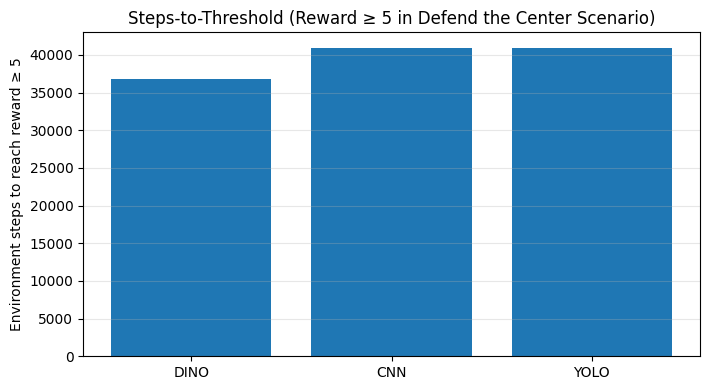

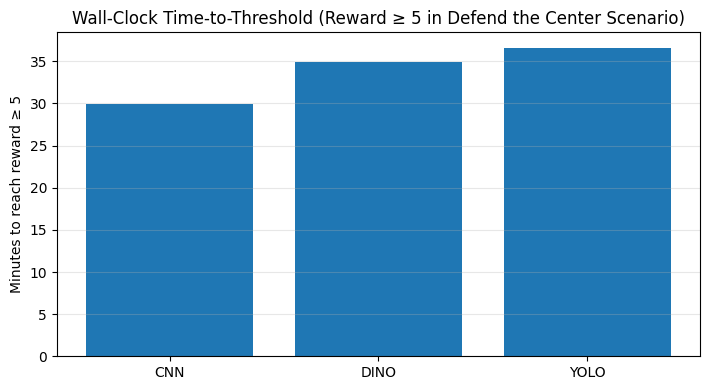

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Your results ----
data = [
    {"Method": "CNN",  "Step_to_5": 40960, "Min_to_5": 29.89},
    {"Method": "YOLO", "Step_to_5": 40960, "Min_to_5": 36.61},
    {"Method": "DINO", "Step_to_5": 36864, "Min_to_5": 34.96},
]

df = pd.DataFrame(data)

# Optional: add relative metrics (vs CNN)
cnn_steps = df.loc[df["Method"] == "CNN", "Step_to_5"].iloc[0]
cnn_mins  = df.loc[df["Method"] == "CNN", "Min_to_5"].iloc[0]

df["Step_ratio_vs_CNN"] = df["Step_to_5"] / cnn_steps
df["Time_ratio_vs_CNN"] = df["Min_to_5"] / cnn_mins
# Sort in "best first" (fastest)
df_steps_sorted = df.sort_values("Step_to_5")
df_time_sorted  = df.sort_values("Min_to_5")

print("\n=== Table: Time/Steps to reach reward ≥ 5 ===")
print(df.to_string(index=False))

# ------------------------
# Plot 1: Steps to threshold
# ------------------------
plt.figure(figsize=(7.2, 4.0))
plt.bar(df_steps_sorted["Method"], df_steps_sorted["Step_to_5"])
plt.ylabel("Environment steps to reach reward ≥ 5")
plt.title("Steps-to-Threshold (Reward ≥ 5 in Defend the Center Scenario)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------
# Plot 2: Minutes to threshold
# ------------------------
plt.figure(figsize=(7.2, 4.0))
plt.bar(df_time_sorted["Method"], df_time_sorted["Min_to_5"])
plt.ylabel("Minutes to reach reward ≥ 5")
plt.title("Wall-Clock Time-to-Threshold (Reward ≥ 5 in Defend the Center Scenario)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
